## Protein distribution 
####   figure 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

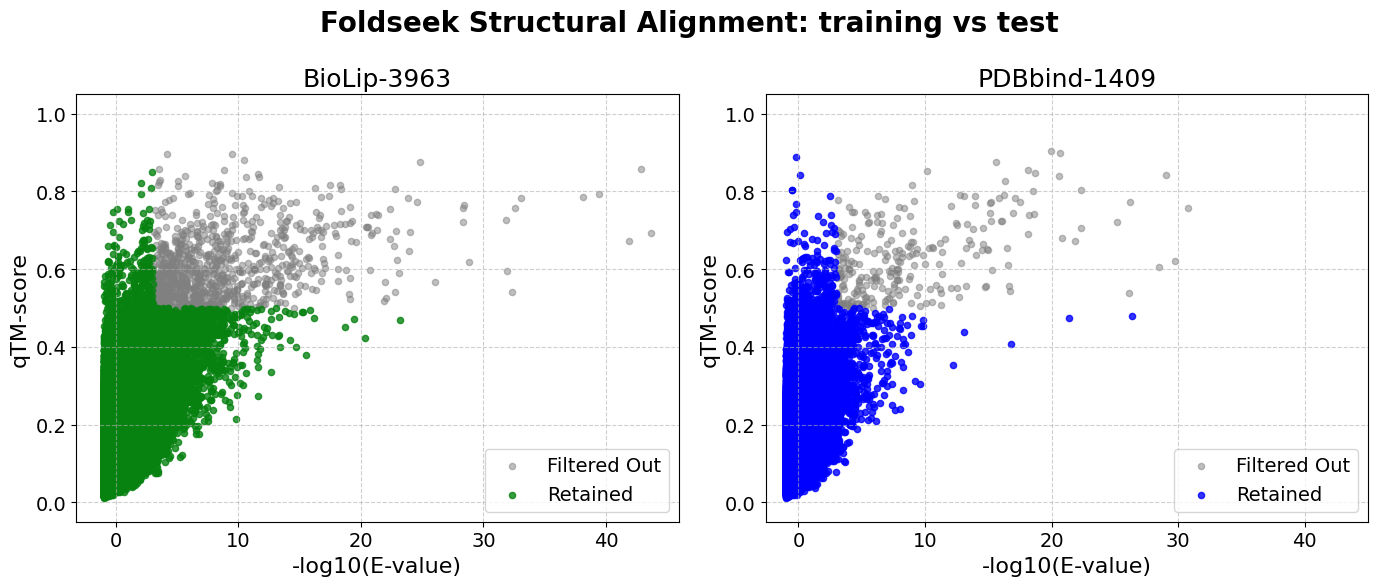

In [21]:
def plot_foldseek_dataset(path, ax, title, retain_color):
    """Helper function to load, transform, and plot a single dataset on a given axis."""
    df = pd.read_csv(path, sep='\t', names=columns)
    
    # --- Data Transformation ---
    # Foldseek can sometimes output an exact 0.0 for e-value. 
    # We replace 0 with a very small number (e.g., 1e-300) to avoid log(0) errors.
    df['evalue_safe'] = df['evalue'].replace(0, 1e-300)
    
    # Calculate -log10 of the e-value
    df['minus_log_evalue'] = -np.log10(df['evalue_safe'])
    
    # --- Define the Mask ---
    condition_mask = (
        (df['query'] != df['target']) & 
        (df['qtmscore'] > 0.5) & 
        (df['evalue'] < 1e-3)
    )
    
    background_df = df[condition_mask]
    highlighted_df = df[~condition_mask]
    
    # --- Plotting ---
    # Background (filtered out) points
    ax.scatter(
        background_df['minus_log_evalue'], 
        background_df['qtmscore'], 
        color='gray', 
        alpha=0.5,      
        label='Filtered Out',
        s=20            
    )
    
    # Highlighted (retained) points
    ax.scatter(
        highlighted_df['minus_log_evalue'], 
        highlighted_df['qtmscore'], 
        color=retain_color, 
        alpha=0.8, 
        label='Retained',
        s=20
    )
    
    # Axis formatting
    ax.set_title(title)
    ax.set_xlabel('-log10(E-value)')
    ax.set_ylabel('qTM-score')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Position legend in the lower right where it's usually empty
    ax.legend(loc='lower right') 

# --- Main Execution ---
path_biolip = "../data_preprocessing/m8_files/BioLip-3693_train_vs_zk448_test.m8"
path_pdbbind = "../data_preprocessing/m8_files/PDBbind-1409_train_vs_zk448_test.m8"

# Create a figure with 1 row, 2 columns. 
# 14x6 is a good aspect ratio for side-by-side plots in a standard LaTeX two-column or full-width layout.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Add the main super title for the entire figure
fig.suptitle('Foldseek Structural Alignment: training vs test', fontweight='bold', fontsize=20)

# Plot BioLip on the left (axes[0])
plot_foldseek_dataset(path_biolip, axes[0], 'BioLip-3963', '#078211')

# Plot PDBbind on the right (axes[1])
plot_foldseek_dataset(path_pdbbind, axes[1], 'PDBbind-1409', 'blue')
axes[1].set_xlim(right=45)

# Apply tight layout to eliminate excess whitespace padding, perfect for Overleaf
# We use h_pad and w_pad to ensure it doesn't overlap with the new suptitle
plt.tight_layout()
plt.show()